# 04 — Classification Models
In this notebook, we build machine learning models to classify flight ticket prices into categories.

Since the original target variable (Price) is continuous, we transform it into discrete classes to convert the problem into a classification task.

We then train and evaluate different classification algorithms and compare their performance.

## Problem Definition

The goal is to predict the price category of a flight ticket based on several features such as:

Airline
Class
Duration
Number of stops
Days left before departure
Departure and arrival time
Source and destination cities

The target variable is:

price_class (categorical variable derived from Price)

The classes represent:

Low price
Medium price
High price

In [45]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, accuracy_score, f1_score

import matplotlib.pyplot as plt


In [46]:
# load the cleaned flight data
df = pd.read_csv("../data/cleaned/flight_data.csv")

# display the first few rows of the dataframe
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
2,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
3,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
4,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955


In [47]:
# create a new column 'price_class' based on the 'price' column using quantiles
df["price_class"] = pd.qcut(df["price"], q=3, labels=["low", "medium", "high"])

In [48]:
# display the first few rows of the dataframe to verify the new column
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,price_class
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,medium
1,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,medium
2,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,medium
3,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,medium
4,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955,medium


In [49]:
# sample the dataframe to reduce the size for faster model training
df_sample = df.sample(50000, random_state=42)

In [50]:
# separate features and target variable
X = df_sample.drop(["price", "price_class"], axis=1)

# target variable
y = df_sample["price_class"]

In [51]:
# identify categorical and numerical columns
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

# print the categorical and numerical columns
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='str')
Numerical columns: Index(['duration', 'days_left'], dtype='str')


C:\Users\flori\AppData\Local\Temp\ipykernel_3264\546256801.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [52]:
# define transformers for numerical and categorical features

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combine transformers into a preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [53]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

In [54]:
# define a dictionary of classification models to evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "SVM": SVC(kernel="rbf")
}

In [55]:
results = []

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append([name, acc, f1])

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

        high       0.99      0.94      0.96      3310
         low       0.80      0.82      0.81      3345
      medium       0.77      0.79      0.78      3345

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


KNN
              precision    recall  f1-score   support

        high       0.94      0.93      0.94      3310
         low       0.83      0.89      0.86      3345
      medium       0.84      0.79      0.82      3345

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


Decision Tree
              precision    recall  f1-score   support

        high       0.97      0.96      0.96      3310
         low       0.92      0.93      0.93      3345
      medium       0.90      0.89 

In [56]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-score"])
results_df

,Model,Accuracy,F1-score
0,Logistic Regression,0.8502,0.851625
1,KNN,0.8701,0.869765
2,Decision Tree,0.9273,0.927327
3,Random Forest,0.8119,0.814650
4,SVM,0.9106,0.911331


In [57]:
best_model = results_df.sort_values(by="F1-score", ascending=False).iloc[0]["Model"]

print("Best Model:", best_model)

Best Model: Decision Tree


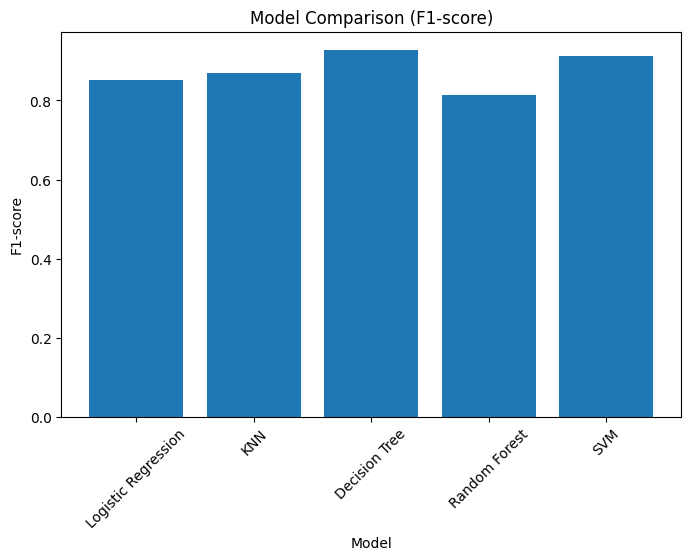

In [58]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["F1-score"])
plt.title("Model Comparison (F1-score)")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=45)
plt.show()

## Conclusion

The Decision Tree model achieved the best performance with the highest Accuracy (0.9273) and F1-score (0.9273), indicating strong ability to capture non-linear patterns in the data.

SVM also performed well (F1-score: 0.9113), followed by KNN (0.8698) and Logistic Regression (0.8516), showing moderate results.

Random Forest performed below expectations (0.8147), likely due to limited hyperparameter tuning.

Overall, tree-based and kernel-based models are the most suitable for this classification task.